## YOLOv8 | Image Size Comparison

**NOTE** This notebook should only be used to display the results. Running it may result in some errors. The effect of ImageSize is provided at the bottom of the notebook.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/YOLOv8 Model Optimization/02_Image Size

/content/drive/MyDrive/YOLOv8 Model Optimization/02_Image Size


In [4]:
%pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 28.9/78.2 GB disk)


# mAP for Image Size Comparison

imgsz:


*   320
*   640

**Results have been obtained using two different Image Size values (320 and 640) for the same model (yolov8l.pt).**

In [5]:
!yolo detect val model=yolov8l.pt data=coco128.yaml iou=0.5 imgsz=320 name=yolov8l_imgsz_320

100% 83.7M/83.7M [00:00<00:00, 169MB/s]
Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8l summary (fused): 268 layers, 43668288 parameters, 0 gradients, 165.2 GFLOPs

Dataset 'coco128.yaml' images not found ⚠️, missing path '/content/drive/MyDrive/YOLOv8 Model Optimization/02_Image Size/datasets/coco128/images/train2017'
100% 6.66M/6.66M [00:00<00:00, 151MB/s]
Unzipping /content/drive/MyDrive/YOLOv8 Model Optimization/02_Image Size/datasets/coco128.zip to /content/drive/MyDrive/YOLOv8 Model Optimization/02_Image Size/datasets/coco128...: 100% 263/263 [00:01<00:00, 132.33file/s]
Dataset download success ✅ (4.0s), saved to /content/drive/MyDrive/YOLOv8 Model Optimization/02_Image Size/datasets

100% 755k/755k [00:00<00:00, 105MB/s]
val: Scanning /content/drive/MyDrive/YOLOv8 Model Optimization/02_Image Size/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% 128/128 [00:01<00:00, 88.97it/s] 
val: New cache created: 

In [6]:
!yolo detect val model=yolov8l.pt data=coco128.yaml iou=0.5 imgsz=640 name=yolov8l_imgsz_640

Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8l summary (fused): 268 layers, 43668288 parameters, 0 gradients, 165.2 GFLOPs
val: Scanning /content/drive/MyDrive/YOLOv8 Model Optimization/02_Image Size/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 8/8 [00:11<00:00,  1.39s/it]
                   all        128        929      0.713      0.783      0.832      0.649
                person        128        254      0.825      0.777      0.856      0.667
               bicycle        128          6      0.845      0.667       0.74      0.518
                   car        128         46       0.86      0.522       0.65      0.349
            motorcycle        128          5      0.777          1      0.962      0.822
              airplane        128          6      0.892          1      

# FPS for Image Size Comparison

In [7]:
from helper import process_video

YOLOv8l - imgsz: 320

In [8]:
video_path = "./inference/test.mp4"
save_path = "./results/test_imgsz320_result.mp4"

model_path = "./yolov8l.pt"

image_size = 320
half_precision = False

process_video(video_path, model_path, save_path, image_size, half_precision)

[INFO]: Video is processing..
[INFO]: Processing task is completed successfully!..
Result video is saved in: ./results/test_imgsz320_result.mp4


YOLOv8l - imgsz: 640

In [9]:
video_path = "./inference/test.mp4"
save_path = "./results/test_imgsz640_result.mp4"

model_path = "./yolov8l.pt"

image_size = 640
half_precision = False

process_video(video_path, model_path, save_path, image_size, half_precision)

[INFO]: Video is processing..
[INFO]: Processing task is completed successfully!..
Result video is saved in: ./results/test_imgsz640_result.mp4


**Resulting Table**:
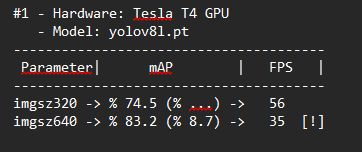

**Comment:**
Although the mAP value for the 640 model was around 83%, the FPS value, despite using a T4 GPU, was close to 30. High FPS allows for faster detection. An FPS value above 30 is desired, and here the result is close to the threshold. This is not an ideal situation. Therefore, in this case, the model with Image Size = 320 may be preferred.
